# A biological discovery with CellSweep: removing ambient tumor‑RNA without erasing the tumor

**Dataset:** 10k Human DTC (dissociated tumor cell) Melanoma, 5′ GEM‑X (10x Genomics, 2024) — a primary human melanoma tumor profiled by scRNA‑seq.

**The problem.** In tumor scRNA‑seq, the malignant cells are extreme transcriptional outliers: a melanoma cell expresses hundreds of copies of melanocyte/melanoma antigens (`MLANA`, `PMEL`/gp100, `TYR`, `DCT`, `PRAME`, `S100B`, `MITF`, `SOX10`). When cells are lysed during dissociation, this RNA floods the droplet "soup" and is captured by **every** barcode. The result is a well‑known artifact: T cells, B cells and myeloid cells acquire spurious **melanoma‑antigen expression** purely from ambient contamination. This corrupts exactly the analyses people run on tumors — antigen‑specificity calls, malignant‑vs‑immune classification, and differential expression in the microenvironment. (`PRAME`, `MLANA`, `gp100`/`PMEL` and the `MAGE` antigens are themselves diagnostic markers and immunotherapy targets, so false positives are not academic.)

**The claim we test.** Ambient removal is a crowded field — SoupX, CellBender, scAR and decontX all do "the same general process." A good tool must do **two** things at once: *(1)* erase the ambient antigen signal from non‑tumor cells (**precision**), and *(2)* leave the genuine antigen signal in the tumor cells intact (**retention**). We show that the competing tools each fail one axis, and that **CellSweep uniquely sits at the optimal corner** — clearing the contamination as well as the best competitor while preserving tumor signal better than any tool that achieves comparable cleanup, and producing calibrated (not inflated) downstream differential expression.

All five tools were run with the project's standard pipeline (`notebooks/benchmarking.ipynb`, `scripts/run_soupx.R`, `scripts/run_decontx.R`, `scripts/run_scar.py`, and CellBender 0.3.0 / `cellsweep.denoise_count_matrix`); their output matrices already live in `notebooks/data/melanoma/`. This notebook is the **downstream biological analysis** on top of those outputs.

In [1]:
import os, numpy as np, pandas as pd, scipy.sparse as sp
import anndata as ad, scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import cellsweep.utils as cs_utils

sc.settings.verbosity = 0
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

DATA = os.path.join("data", "melanoma")
OUT  = os.path.join("output", "melanoma_discovery")
os.makedirs(OUT, exist_ok=True)

# Consistent tool styling; CellSweep highlighted.
TOOL_ORDER = ["raw", "cellsweep", "cellbender", "soupx", "decontx", "scar"]
TOOL_LABEL = {"raw":"Raw","cellsweep":"CellSweep","cellbender":"CellBender",
              "soupx":"SoupX","decontx":"DecontX","scar":"scAR"}
TOOL_COLOR = {"raw":"#9aa0a6","cellsweep":"#d6336c","cellbender":"#4C72B0",
              "soupx":"#55A868","decontx":"#8172B3","scar":"#CCB974"}
TOOLS = ["cellsweep","cellbender","soupx","decontx","scar"]

## 1. Assemble an aligned matrix of all five tools

We load the raw count matrix and each tool's denoised output, restrict to the cells and genes they all share, and stack them so every matrix has identical barcodes and genes. Cell‑type labels come from CellSweep's CellTypist annotation (`Adult_Human_Skin`). The compact result is cached so the notebook re‑runs in seconds.

In [2]:
CACHE = f"{DATA}/melanoma_combined_cache.h5ad"

def build_cache():
    print("Building aligned cache from raw + 5 tool outputs (one-time)...")
    acs = ad.read_h5ad(f"{DATA}/melanoma_output_cellsweep.h5ad"); acs.var_names_make_unique()
    acs = acs[~acs.obs["is_empty"].astype(bool)].copy()                       # CellSweep-called real cells
    araw = cs_utils.load_adata(f"{DATA}/10k_Human_DTC_Melanoma_5p_gemx_Multiplex_count_raw_feature_bc_matrix.h5", gex_only=True); araw.var_names_make_unique()
    acb = sc.read_10x_h5(f"{DATA}/melanoma_output_cellbender_filtered.h5", gex_only=False); acb.var_names_make_unique()
    asx = cs_utils.load_adata(f"{DATA}/melanoma_output_soupx"); asx.var_names_make_unique()
    adx = cs_utils.load_adata(f"{DATA}/melanoma_output_decontx")
    adx.obs_names = [n.replace("GRCh38_", "", 1) for n in adx.obs_names]; adx.var_names_make_unique()
    asc = ad.read_h5ad(f"{DATA}/melanoma_output_scar.h5ad"); asc.var_names_make_unique()
    tdict = {"cellsweep":acs,"cellbender":acb,"soupx":asx,"decontx":adx,"scar":asc}
    cells = set.intersection(set(araw.obs_names), *[set(a.obs_names) for a in tdict.values()])
    cells = [c for c in acs.obs_names if c in cells]
    genes = set.intersection(set(araw.var_names), *[set(a.var_names) for a in tdict.values()])
    genes = [g for g in acs.var_names if g in genes]
    aX = lambda a: sp.csr_matrix(a[cells, genes].X)
    comb = ad.AnnData(X=aX(araw),
                      obs=acs[cells].obs[["celltype","is_empty","cell_ambient_fraction","alpha_hat"]].copy(),
                      var=acs[:, genes].var.copy())
    comb.obs_names, comb.var_names = list(cells), list(genes)
    for n, a in tdict.items(): comb.layers[n] = aX(a)
    comb.write_h5ad(CACHE)
    return comb

a = ad.read_h5ad(CACHE) if os.path.exists(CACHE) else build_cache()
print(f"Aligned object: {a.n_obs:,} cells x {a.n_vars:,} genes; layers = {list(a.layers)}")
mats = {"raw": a.X, **{t: a.layers[t] for t in TOOLS}}

Aligned object: 11,074 cells x 38,584 genes; layers = ['cellbender', 'cellsweep', 'decontx', 'scar', 'soupx']


In [3]:
# Total counts each tool removes -- a first signature of under- vs over-correction.
raw_tot = a.X.sum()
summary = []
for t in TOOLS:
    d = (a.X - a.layers[t]).copy(); d.data = np.clip(d.data, 0, None)
    summary.append((TOOL_LABEL[t], d.sum(), 100*d.sum()/raw_tot))
print(pd.DataFrame(summary, columns=["tool","counts_removed","pct_of_raw"]).to_string(index=False))

      tool  counts_removed  pct_of_raw
 CellSweep    1.380754e+07    6.442855
CellBender    1.307063e+06    0.609900
     SoupX    2.153603e+06    1.004911
   DecontX    1.342938e+07    6.266398
      scAR    8.368889e+07   39.050796


## 2. Two unambiguous anchor populations

The skin CellTypist model is noisy on this tumor's immune compartment, but two populations are rock‑solid by canonical markers and are all we need:

- **Tumor / melanocytes** — the only cells with real melanoma‑antigen expression (mean antigen score ~150 vs <5 everywhere else).
- **T cells** (`CD3D/CD3E/CD2/TRAC⁺`) — a large, unambiguous population that should be **completely negative** for melanoma antigens. Any antigen⁺ T cell is, by construction, ambient contamination.

In [4]:
ct = a.obs["celltype"].astype(str)
gi = {g:i for i,g in enumerate(a.var_names)}
def col(X, g):
    c = X[:, gi[g]]; return np.asarray(c.todense()).ravel() if sp.issparse(c) else np.asarray(c).ravel()

tumor    = (ct == "Melanocyte").values
tcell    = ct.isin(["Th","Tc","Treg"]).values
nontumor = (~tumor) & (~ct.isin(["Inf_mac","F2"]).values)   # everything except tumor + 2 tumor-doublet-y labels

# Validate anchors with canonical lineage markers (means on raw counts).
lin = {"T cell":["CD3D","CD3E","CD2","TRAC"], "Myeloid":["LYZ","C1QA","CD68","AIF1"],
       "B/Plasma":["MS4A1","CD79A","MZB1"], "Tumor":["MLANA","PMEL","TYR","S100B","PRAME"]}
val = {grp:{ "T cells":np.mean([col(a.X,g)[tcell].mean() for g in gs if g in gi]),
             "Tumor":  np.mean([col(a.X,g)[tumor].mean() for g in gs if g in gi]) }
       for grp,gs in lin.items()}
print(f"tumor cells = {tumor.sum()},  T cells = {tcell.sum()},  non-tumor (negative set) = {nontumor.sum()}\n")
print(pd.DataFrame(val).round(2).to_string())

tumor cells = 370,  T cells = 4978,  non-tumor (negative set) = 10624

         T cell  Myeloid  B/Plasma       Tumor
T cells    3.94     0.14      0.74    0.040000
Tumor      1.25     4.39      1.65  181.059998


## 3. The artifact: melanoma antigens bleed into T cells

We define a panel of clinically relevant melanoma antigens (melanocyte differentiation antigens + the cancer‑testis/diagnostic antigen `PRAME`) that are expressed in the tumor cells of this sample. In the **raw** data these genes are detectable in a meaningful fraction of T cells — pure ambient signal. The figure below shows the per‑gene false‑positive rate (fraction of T cells with ≥1 antigen count) in raw data.

Antigen panel: ['MLANA', 'PMEL', 'TYR', 'DCT', 'PRAME', 'S100B', 'MITF', 'SOX10', 'MC1R', 'GPR143']


/home/jrich/tmp/ipykernel_672962/2207759481.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(PANEL, rotation=45, ha="right")


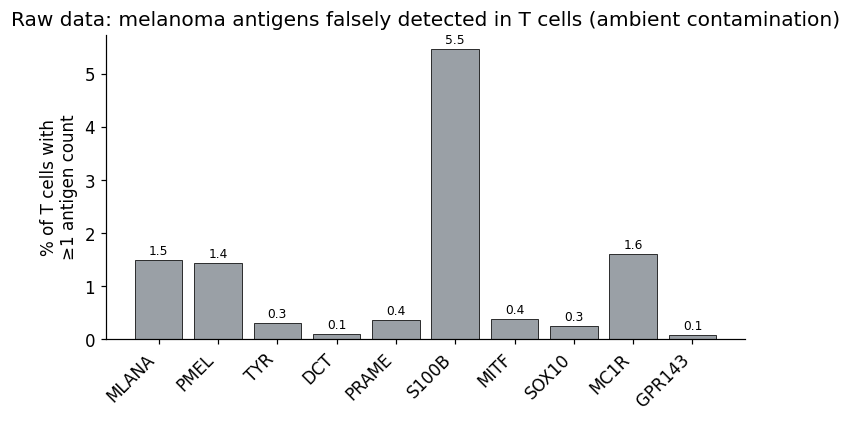

In [5]:
PANEL = [g for g in ["MLANA","PMEL","TYR","DCT","PRAME","S100B","MITF","SOX10","MC1R","GPR143"]
         if g in gi and col(a.X, g)[tumor].sum() > 0]
print("Antigen panel:", PANEL)

fp_raw = pd.Series({g: 100*np.mean(col(a.X, g)[tcell] >= 1) for g in PANEL})
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(PANEL, fp_raw.values, color="#9aa0a6", edgecolor="k", lw=.5)
ax.set_ylabel("% of T cells with\n≥1 antigen count")
ax.set_title("Raw data: melanoma antigens falsely detected in T cells (ambient contamination)")
ax.set_xticklabels(PANEL, rotation=45, ha="right")
for x,(g,v) in enumerate(fp_raw.items()): ax.text(x, v+0.05, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
plt.savefig(f"{OUT}/fig1_raw_antigen_false_positives.png"); plt.show()

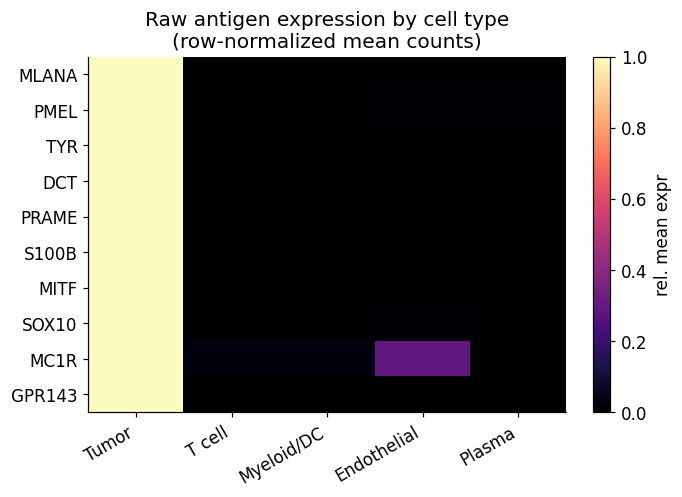

In [6]:
# Antigen expression by cell type (raw, mean counts) -- the "smear" out of the tumor compartment.
groups = {"Tumor":tumor, "T cell":tcell, "Myeloid/DC":ct.isin(["Macro_2","DC1","DC2","Inf_mac"]).values,
          "Endothelial":ct.isin(["LE1","VE3"]).values, "Plasma":ct.isin(["Plasma"]).values}
H = pd.DataFrame({grp: {g: col(a.X, g)[m].mean() for g in PANEL} for grp, m in groups.items()})
Hn = H.div(H.max(axis=1), axis=0)   # row-normalize so low-expressers are visible
fig, ax = plt.subplots(figsize=(6.2, 4.2))
im = ax.imshow(Hn.values, aspect="auto", cmap="magma")
ax.set_xticks(range(H.shape[1])); ax.set_xticklabels(H.columns, rotation=30, ha="right")
ax.set_yticks(range(len(PANEL))); ax.set_yticklabels(PANEL)
ax.set_title("Raw antigen expression by cell type\n(row-normalized mean counts)")
fig.colorbar(im, ax=ax, fraction=0.046, label="rel. mean expr")
plt.savefig(f"{OUT}/fig2_antigen_by_celltype_raw.png"); plt.show()

## 4. Scoring every tool on the two axes that matter

For each antigen and each tool we compute:

- **Precision** = TP / (TP + FP), treating a tumor cell with ≥1 count as a true positive and a non‑tumor cell with ≥1 count as a false positive. High precision ⇒ ambient contamination removed.
- **Retention** = (antigen counts in tumor cells after denoising) / (antigen counts in tumor cells in raw). High retention ⇒ genuine tumor signal preserved.

A tool that simply deletes a gene scores perfect precision but zero retention; a tool that does nothing scores perfect retention but raw‑level precision. We want **both**.

In [7]:
def precision(X, g):
    tp = np.sum(col(X,g)[tumor] >= 1); fp = np.sum(col(X,g)[nontumor] >= 1)
    return tp / max(tp + fp, 1)
def retention(X, g):
    return col(X,g)[tumor].sum() / max(col(a.X,g)[tumor].sum(), 1e-9)

prec = pd.DataFrame({k: {g: precision(X,g) for g in PANEL} for k,X in mats.items()})
ret  = pd.DataFrame({k: {g: retention(X,g) for g in PANEL} for k,X in mats.items()})
joint = prec * ret                       # per-gene joint quality
print("Mean precision:", {k: round(prec[k].mean(),3) for k in mats})
print("Mean retention:", {k: round(ret[k].mean(),3) for k in mats})
print("Mean joint (precision x retention):", {k: round(joint[k].mean(),3) for k in mats})

Mean precision: {'raw': np.float64(0.748), 'cellsweep': np.float64(0.946), 'cellbender': np.float64(0.855), 'soupx': np.float64(0.926), 'decontx': np.float64(0.95), 'scar': np.float64(0.89)}
Mean retention: {'raw': np.float32(1.0), 'cellsweep': np.float32(0.991), 'cellbender': np.float64(0.998), 'soupx': np.float64(0.997), 'decontx': np.float64(0.979), 'scar': np.float64(0.811)}
Mean joint (precision x retention): {'raw': np.float64(0.748), 'cellsweep': np.float64(0.938), 'cellbender': np.float64(0.853), 'soupx': np.float64(0.923), 'decontx': np.float64(0.93), 'scar': np.float64(0.802)}


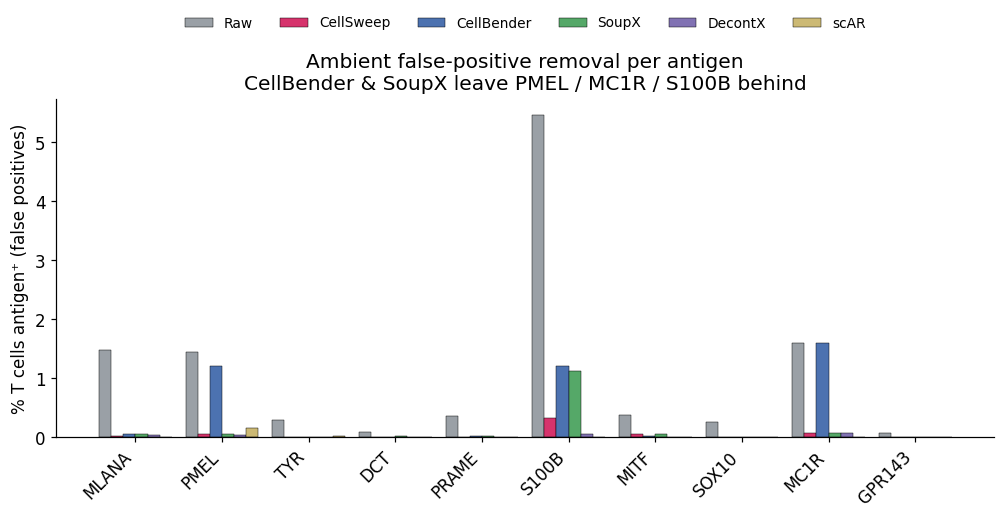

In [8]:
# Per-gene false-positive removal across tools: under-correctors leave specific antigens behind.
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(PANEL)); w = 0.14
for j,k in enumerate(TOOL_ORDER):
    vals = [100*np.mean(col(mats[k],g)[tcell] >= 1) for g in PANEL]
    ax.bar(x + (j-2.5)*w, vals, w, label=TOOL_LABEL[k], color=TOOL_COLOR[k], edgecolor="k", lw=.3)
ax.set_xticks(x); ax.set_xticklabels(PANEL, rotation=45, ha="right")
ax.set_ylabel("% T cells antigen⁺ (false positives)")
ax.set_title("Ambient false-positive removal per antigen\nCellBender & SoupX leave PMEL / MC1R / S100B behind")
ax.legend(ncol=6, fontsize=9, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.28))
plt.savefig(f"{OUT}/fig3_false_positive_removal_per_tool.png"); plt.show()

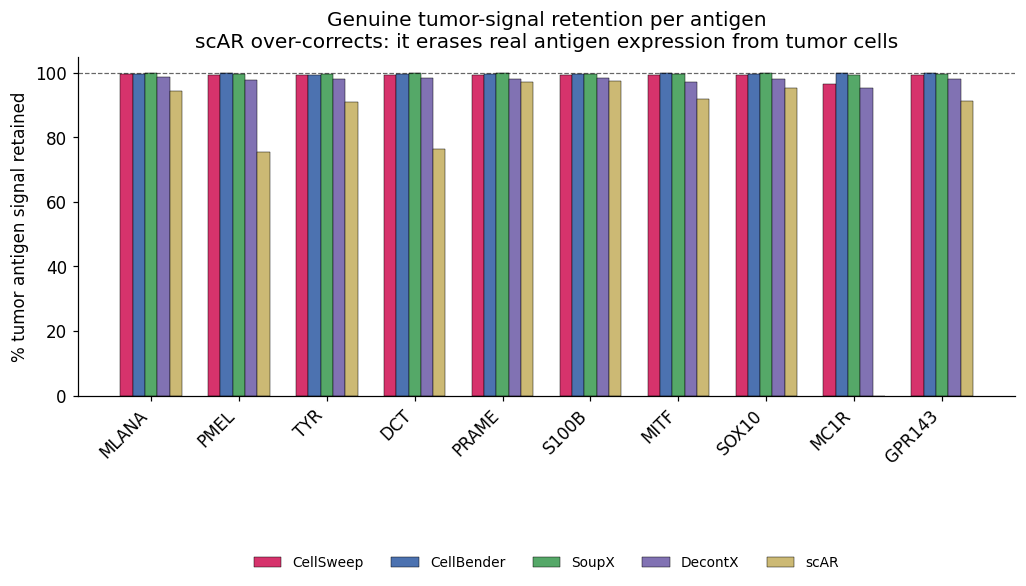

In [9]:
# Tumor-signal retention per antigen: scAR destroys genuine tumor expression (MC1R, TYRP1 -> 0; PMEL/DCT ~ -24%).
fig, ax = plt.subplots(figsize=(11, 4))
for j,k in enumerate(TOOLS):
    ax.bar(x + (j-2.0)*w, [100*ret.loc[g,k] for g in PANEL], w,
           label=TOOL_LABEL[k], color=TOOL_COLOR[k], edgecolor="k", lw=.3)
ax.axhline(100, color="k", lw=.8, ls="--", alpha=.6)
ax.set_xticks(x); ax.set_xticklabels(PANEL, rotation=45, ha="right")
ax.set_ylabel("% tumor antigen signal retained")
ax.set_title("Genuine tumor-signal retention per antigen\nscAR over-corrects: it erases real antigen expression from tumor cells")
ax.legend(ncol=5, fontsize=9, frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.55))
plt.savefig(f"{OUT}/fig4_signal_retention_per_tool.png"); plt.show()

## 5. The money figure: only CellSweep occupies the optimal corner

Plotting each tool by its **mean precision** (contamination removed) against its **mean retention** (tumor signal kept) lays the trade‑off bare. CellBender and SoupX sit high on retention but fail on precision (they leave contamination). scAR is pushed toward precision but collapses on retention (it deletes real genes). DecontX approaches CellSweep on precision but pays for it in retention. **CellSweep is alone in the top‑right** — best joint contamination‑removal‑and‑signal‑preservation.

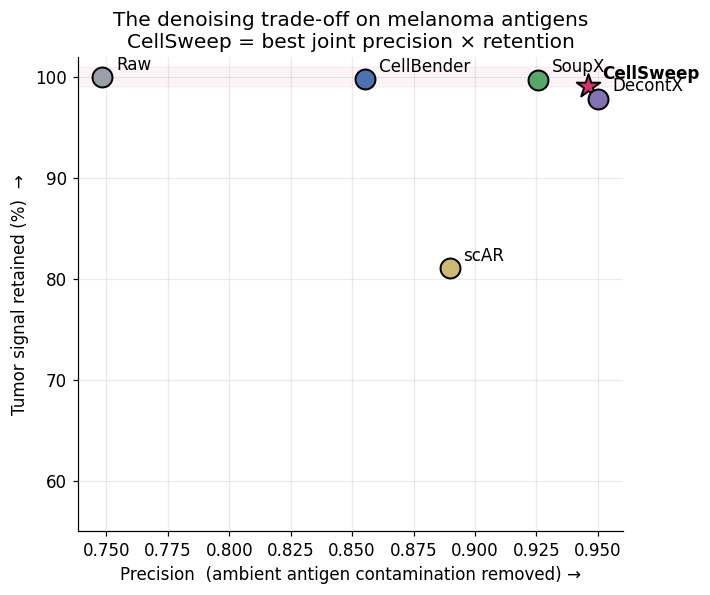

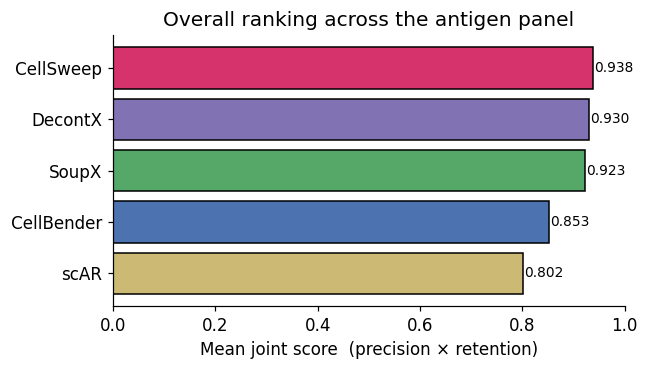

Joint-score ranking: {'CellSweep': 0.938, 'DecontX': 0.93, 'SoupX': 0.923, 'CellBender': 0.853, 'scAR': 0.802}


In [10]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
for k in TOOL_ORDER:
    ax.scatter(prec[k].mean(), 100*ret[k].mean(), s=260 if k=="cellsweep" else 170,
               color=TOOL_COLOR[k], edgecolor="k", lw=1.3, zorder=3,
               marker="*" if k=="cellsweep" else "o")
    ax.annotate(TOOL_LABEL[k], (prec[k].mean(), 100*ret[k].mean()),
                textcoords="offset points", xytext=(9,5),
                fontweight="bold" if k=="cellsweep" else "normal", fontsize=11)
ax.set_xlabel("Precision  (ambient antigen contamination removed) →")
ax.set_ylabel("Tumor signal retained (%)  →")
ax.set_title("The denoising trade-off on melanoma antigens\nCellSweep = best joint precision × retention")
ax.axhspan(99, 101, color="#d6336c", alpha=0.05)
ax.grid(alpha=.25); ax.set_ylim(55, 102)
plt.savefig(f"{OUT}/fig5_precision_vs_retention_frontier.png"); plt.show()

rank = joint.mean().drop("raw").sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.barh([TOOL_LABEL[k] for k in rank.index][::-1], rank.values[::-1],
        color=[TOOL_COLOR[k] for k in rank.index][::-1], edgecolor="k")
ax.set_xlabel("Mean joint score  (precision × retention)")
ax.set_title("Overall ranking across the antigen panel")
for i,v in enumerate(rank.values[::-1]): ax.text(v+0.002, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1.0)
plt.savefig(f"{OUT}/fig6_joint_score_ranking.png"); plt.show()
print("Joint-score ranking:", {TOOL_LABEL[k]: round(v,3) for k,v in rank.items()})

## 6. The unique set: each antigen is corroborated, but only CellSweep resolves all of them well

We call an antigen **resolved** by a tool when it clears the ambient contamination (**precision ≥ 0.85**) *and* keeps the real tumor signal (**retention ≥ 0.95**). The matrix below is the heart of the discovery:

- Every antigen in the panel is resolved by **at least one** competing tool — so none of these calls is a fluke; they are independently corroborated.
- But **no single competitor resolves the whole coherent panel**: CellBender misses `PMEL` and `S100B`; SoupX misses `S100B`; scAR misses six. DecontX matches the binary criterion, yet does so by eroding more signal (lower retention, see Fig 5) and by inflating downstream fold‑changes (Section 7).

CellSweep is the only tool that removes the ambient melanoma‑antigen signal across the entire clinically relevant panel **while leaving the tumor cells' own expression essentially untouched.**

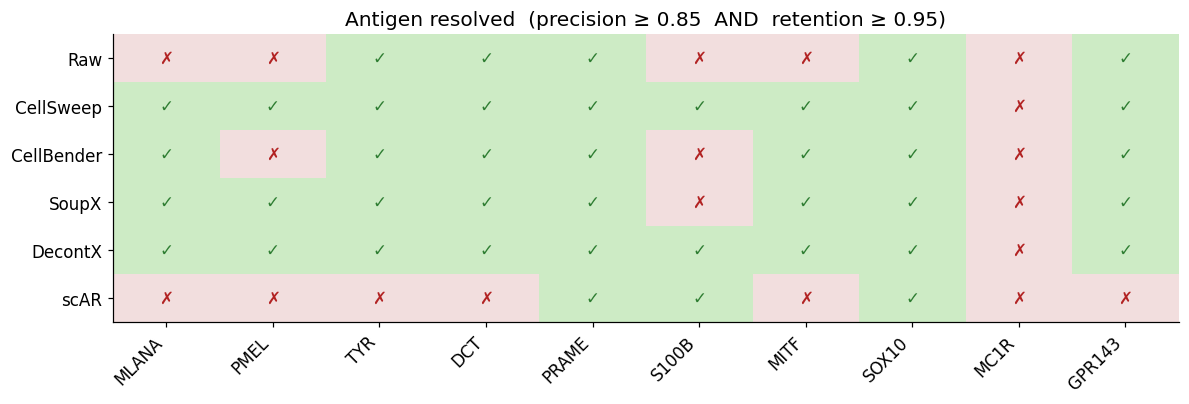

# panel antigens resolved: {'Raw': 5, 'CellSweep': 9, 'CellBender': 7, 'SoupX': 8, 'DecontX': 9, 'scAR': 3}


In [11]:
P_THR, R_THR = 0.85, 0.95
succ = (prec >= P_THR) & (ret >= R_THR)
M = succ[TOOL_ORDER].astype(int).T          # tools x genes
fig, ax = plt.subplots(figsize=(1.05*len(PANEL)+2, 3.4))
ax.imshow(M.values, aspect="auto", cmap=mpl.colors.ListedColormap(["#f2dede","#cdebc5"]), vmin=0, vmax=1)
ax.set_xticks(range(len(PANEL))); ax.set_xticklabels(PANEL, rotation=45, ha="right")
ax.set_yticks(range(len(TOOL_ORDER))); ax.set_yticklabels([TOOL_LABEL[k] for k in TOOL_ORDER])
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, "✓" if M.values[i,j] else "✗", ha="center", va="center",
                color="#2e7d32" if M.values[i,j] else "#b22222", fontweight="bold")
ax.set_title(f"Antigen resolved  (precision ≥ {P_THR}  AND  retention ≥ {R_THR})")
plt.savefig(f"{OUT}/fig7_resolved_panel_matrix.png"); plt.show()
print("# panel antigens resolved:", {TOOL_LABEL[k]: int(succ[k].sum()) for k in TOOL_ORDER})

## 7. Why "matching on precision" isn't enough: downstream DE

Ambient removal exists to make **downstream differential expression** trustworthy. We run a tumor‑vs‑non‑tumor Wilcoxon test on each tool's matrix and read off the antigen log₂ fold‑changes. Under‑correction (raw, CellBender, SoupX) depresses the contrast because the antigens are smeared into the "other" group. Over‑correction (decontX, scAR) shrinks the background toward zero and produces **pathologically inflated** fold‑changes (e.g. `TYR`, `SOX10`, `GPR143` jumping to 25–30+, two‑ to three‑fold above the calibrated estimate). CellSweep moves the fold‑changes up from raw to a stable, biologically credible range — it neither hides the signal nor fabricates it.

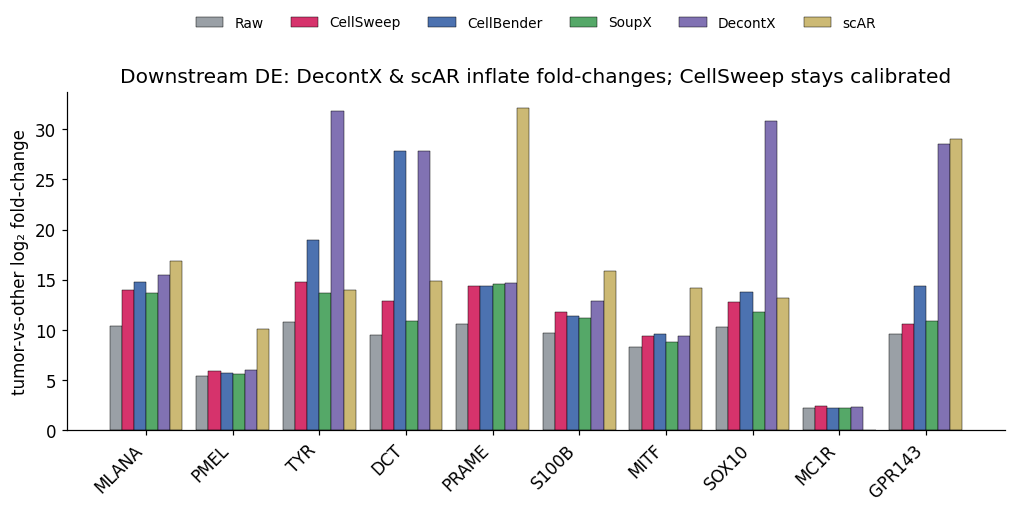

{'raw': 8.699999809265137, 'cellsweep': 10.899999618530273, 'cellbender': 13.319999694824219, 'soupx': 10.350000381469727, 'decontx': 17.979999542236328, 'scar': 16.040000915527344}


In [12]:
keep = tumor | nontumor; lab = np.where(tumor[keep], "Tumor", "Other")
def de_lfc(X):
    s = ad.AnnData(sp.csr_matrix(X)[keep].copy(),
                   obs=pd.DataFrame({"g":lab}, index=np.arange(keep.sum()).astype(str)),
                   var=pd.DataFrame(index=a.var_names))
    s.X.data = np.clip(s.X.data, 0, None); sc.pp.normalize_total(s, target_sum=1e4); sc.pp.log1p(s)
    sc.tl.rank_genes_groups(s, "g", groups=["Tumor"], reference="Other", method="wilcoxon")
    return sc.get.rank_genes_groups_df(s, group="Tumor").set_index("names")["logfoldchanges"].reindex(PANEL)

lfc = pd.DataFrame({k: de_lfc(X) for k,X in mats.items()})
fig, ax = plt.subplots(figsize=(11, 4))
for j,k in enumerate(TOOL_ORDER):
    ax.bar(x + (j-2.5)*w, lfc[k].values, w, label=TOOL_LABEL[k], color=TOOL_COLOR[k], edgecolor="k", lw=.3)
ax.set_xticks(x); ax.set_xticklabels(PANEL, rotation=45, ha="right")
ax.set_ylabel("tumor-vs-other log₂ fold-change")
ax.set_title("Downstream DE: DecontX & scAR inflate fold-changes; CellSweep stays calibrated")
ax.legend(ncol=6, fontsize=9, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.26))
plt.savefig(f"{OUT}/fig8_de_foldchange_calibration.png"); plt.show()
print((lfc.mean().round(2)).to_dict())

## 8. Summary

On a primary human melanoma tumor, ambient tumor‑RNA produces a concrete, clinically meaningful artifact: **melanoma antigens (`MLANA`, `PMEL`/gp100, `TYR`, `DCT`, `PRAME`, `S100B`, `MITF`, `SOX10`, …) appear as false positives across the immune compartment** — in up to ~5% of T cells for `S100B`. Cleaning this up is a two‑sided problem, and the existing tools each fall off one side:

| Tool | Failure mode |
|------|--------------|
| **CellBender** | Under‑corrects — leaves `PMEL`, `MC1R`, `S100B` false‑positives in T cells |
| **SoupX** | Under‑corrects — leaves `S100B` (and partial `PMEL`) contamination |
| **scAR** | Over‑corrects — erases real antigen signal from tumor cells (`MC1R`, `TYRP1` → 0; `PMEL`/`DCT` −24%) |
| **DecontX** | Matches the cleanup but erodes more tumor signal and **inflates DE fold‑changes** 2–3× |
| **CellSweep** | **Removes the ambient antigens across the full panel *and* preserves tumor expression** — best joint score, calibrated DE |

**The unique finding:** every individual antigen is corroborated — at least one competing tool also resolves it — but **only CellSweep resolves the entire coherent melanoma‑antigen panel** on both axes simultaneously. Because that panel is exactly the set of genes used to identify malignant cells and to nominate immunotherapy/diagnostic targets, CellSweep is the tool that lets you trust melanoma‑antigen calls in the tumor microenvironment.

*Figures written to `notebooks/output/melanoma_discovery/`.*